# Coherence Signal Diagnostic

**Purpose:** Determine whether the post-mowing coherence increase (Tamm et al. 2016) is
visible in the existing `data/features_coherence/` rasters, stratified by season and
parcel-level GT label.

**Kernel:** Run in the **BA** conda environment — requires `geopandas`, `rasterio`, `scipy`.
In VS Code: *Kernel → Select Another Kernel → BA*.

> **Temporary file — delete after use.**


In [11]:
import os, glob, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask as rio_mask
import matplotlib.pyplot as plt
from scipy import stats
warnings.filterwarnings('ignore')

%matplotlib inline

BASE      = "c:/Workspace/ZHAW/6_Semester/satellite-mowing-detection"
COH_DIR   = f"{BASE}/data/features_coherence"
MASKS_DIR = f"{BASE}/data/ground_truth_masks"
AV_GPKG   = f"{BASE}/data/amtliche_vermessung_zh/DM01AVZH24LV95.gpkg"
TM_CSV    = f"{BASE}/data/temporal_matches.csv"
SLC_CSV   = f"{BASE}/data/slc_event_coverage.csv"

MOWED_FRAC_THRESHOLD = 0.30   # ≥30% GT coverage → parcel labelled "mowed"
MIN_COH_PIXELS       = 2      # parcels with fewer valid pixels in coh are skipped

print("Paths configured.")


Paths configured.


## Step 1 — Events with validated coherence TIFs

In [12]:
tm  = pd.read_csv(TM_CSV, parse_dates=['event_date'])
slc = pd.read_csv(SLC_CSV)

# Join on event_date_str to attach calendar date to each match_id
events = slc.merge(
    tm[['event_date_str', 'event_date']].drop_duplicates('event_date_str'),
    on='event_date_str', how='left'
)
events['event_date'] = pd.to_datetime(events['event_date'])
events = events.dropna(subset=['event_date']).copy()


def get_coh_band_indices(src):
    """Return 0-based (vv_idx, vh_idx) by scanning for bands whose values lie in [0,1]."""
    coh = []
    for b in range(1, src.count + 1):
        win = rasterio.windows.Window(0, 0, min(200, src.width), min(200, src.height))
        arr = src.read(b, window=win).astype(float)
        valid = arr[(arr > 0.001) & np.isfinite(arr)]
        if valid.size > 50 and valid.max() <= 1.0:
            coh.append(b - 1)   # store as 0-based
    vv = coh[0] if len(coh) > 0 else None
    vh = coh[1] if len(coh) > 1 else None
    return vv, vh


def quick_validate(path):
    """Return (ok, (vv_idx, vh_idx)) for a coherence TIF."""
    if not os.path.exists(path):
        return False, (None, None)
    try:
        with rasterio.open(path) as src:
            vv, vh = get_coh_band_indices(src)
            if vv is None:
                return False, (None, None)
            return True, (vv, vh)
    except Exception:
        return False, (None, None)


# Identify events with both TIFs present AND passing band-structure check
before_ids = {int(os.path.basename(f).split('_')[0])
              for f in glob.glob(f"{COH_DIR}/*_coh_before.tif")}
after_ids  = {int(os.path.basename(f).split('_')[0])
              for f in glob.glob(f"{COH_DIR}/*_coh_after.tif")}
candidate_ids = before_ids & after_ids

valid_records = []
for mid in sorted(candidate_ids):
    ok_b, bands_b = quick_validate(f"{COH_DIR}/{mid}_coh_before.tif")
    ok_a, bands_a = quick_validate(f"{COH_DIR}/{mid}_coh_after.tif")
    if ok_b and ok_a:
        valid_records.append({'match_id': mid, 'vv_b': bands_b[0], 'vh_b': bands_b[1],
                               'vv_a': bands_a[0], 'vh_a': bands_a[1]})

band_df = pd.DataFrame(valid_records)
events_valid = events[events['match_id'].isin(band_df['match_id'])].merge(band_df, on='match_id')
events_valid = events_valid.sort_values('event_date').reset_index(drop=True)

print(f"Events with both TIFs on disk:       {len(candidate_ids)}")
print(f"Events passing coherence band check: {len(events_valid)}")
print(f"Date range: {events_valid['event_date'].min().date()} – {events_valid['event_date'].max().date()}")
print()
disp = events_valid[['match_id','event_date','baseline_before','baseline_after']].copy()
disp['event_date'] = disp['event_date'].dt.date
print(disp.to_string(index=False))


Events with both TIFs on disk:       45
Events passing coherence band check: 45
Date range: 2019-05-09 – 2021-09-03

 match_id event_date  baseline_before  baseline_after
        0 2019-05-09                6               6
        1 2019-05-16                6               6
        2 2019-05-23                6               6
        3 2019-05-30                6               6
        4 2019-05-31                6               6
        5 2019-06-05                6               6
        6 2019-06-06                6               6
        7 2019-06-16                6               6
        8 2019-06-17                6               6
        9 2019-06-18                6               6
       10 2019-06-19               12              12
       11 2019-06-20                6              12
       12 2019-06-23                6              12
       15 2019-07-02               12               6
       16 2019-07-03               12               6
       17 2019-07-0

## Step 2 — Season grouping

In [13]:
def assign_season(date):
    m = date.month
    if m in (4, 5):        return 'early'
    if m in (6, 7):        return 'peak'
    if m in (8, 9, 10):    return 'late'
    return 'other'

events_valid['season'] = events_valid['event_date'].apply(assign_season)

SEASON_ORDER  = ['early', 'peak', 'late', 'other']
SEASON_LABELS = {
    'early': 'Early season (Apr–May)',
    'peak':  'Peak growth (Jun–Jul)',
    'late':  'Late season (Aug–Oct)',
    'other': 'Other',
}

counts = events_valid['season'].value_counts().reindex(SEASON_ORDER).fillna(0).astype(int)
print("Events per season:")
for s, n in counts.items():
    print(f"  {SEASON_LABELS.get(s, s):<30s}  {n}")


Events per season:
  Early season (Apr–May)          8
  Peak growth (Jun–Jul)           26
  Late season (Aug–Oct)           11
  Other                           0


## Steps 3–4 — Load AV grassland parcels (once)

In [14]:
print("Loading AV layer …")
av_all = gpd.read_file(AV_GPKG, layer='Bodenbedeckung_BoFlaeche_Area')
av = av_all[av_all['Art_TXT'] == 'humusiert.Acker_Wiese_Weide'].copy().reset_index(drop=True)
av['parcel_area_m2'] = av.geometry.area

print(f"Grassland parcels in AV layer:  {len(av)}")
print(f"CRS:                            {av.crs}")
print(f"Area range:  {av['parcel_area_m2'].min():.0f} – {av['parcel_area_m2'].max():.0f} m²  "
      f"(median {av['parcel_area_m2'].median():.0f} m²)")


Loading AV layer …
Grassland parcels in AV layer:  577
CRS:                            EPSG:2056
Area range:  4 – 158269 m²  (median 7138 m²)


## Step 3 — Per-parcel coherence statistics

In [15]:
from shapely.geometry import box

def parcel_mean_coh(src, geom, band_0idx):
    """Mean coherence inside parcel geometry. Returns nan if insufficient valid pixels."""
    try:
        arr, _ = rio_mask(src, [geom], crop=True, filled=True, nodata=np.nan,
                          indexes=band_0idx + 1, all_touched=False)
        arr = arr.astype(float)
        valid = arr[(np.isfinite(arr)) & (arr > 0.001)]
        return float(np.mean(valid)) if valid.size >= MIN_COH_PIXELS else np.nan
    except Exception:
        return np.nan


def parcel_gt_frac(gt_src, geom):
    """Fraction of parcel area labelled 1 (mowed) in binary GT mask (nodata=255)."""
    try:
        arr, _ = rio_mask(gt_src, [geom], crop=True, filled=True, nodata=255,
                          indexes=1, all_touched=False)
        arr = arr.astype(np.uint8).ravel()
        valid = arr[arr != 255]
        return float(np.sum(valid == 1) / valid.size) if valid.size > 0 else np.nan
    except Exception:
        return np.nan


records = []

for _, ev in events_valid.iterrows():
    mid       = int(ev['match_id'])
    ev_date   = ev['event_date']
    season    = ev['season']
    date_str  = str(int(ev['event_date_str']))

    bp = f"{COH_DIR}/{mid}_coh_before.tif"
    ap = f"{COH_DIR}/{mid}_coh_after.tif"
    mp = f"{MASKS_DIR}/mask_{date_str}.tif"

    if not os.path.exists(mp):
        print(f"  [SKIP] GT mask not found: mask_{date_str}.tif")
        continue

    vv_b, vh_b = int(ev['vv_b']), (int(ev['vh_b']) if pd.notna(ev['vh_b']) else None)
    vv_a, vh_a = int(ev['vv_a']), (int(ev['vh_a']) if pd.notna(ev['vh_a']) else None)

    with rasterio.open(bp) as src_b, rasterio.open(ap) as src_a,          rasterio.open(mp) as src_gt:

        # Restrict to parcels that intersect the coherence raster footprint
        coh_bbox   = box(*src_b.bounds)
        av_sub = av[av.intersects(coh_bbox)].copy()

        for _, p in av_sub.iterrows():
            geom = p.geometry

            gt_frac = parcel_gt_frac(src_gt, geom)
            if np.isnan(gt_frac):
                continue

            bef_vv = parcel_mean_coh(src_b, geom, vv_b)
            aft_vv = parcel_mean_coh(src_a, geom, vv_a)
            bef_vh = parcel_mean_coh(src_b, geom, vh_b) if vh_b is not None else np.nan
            aft_vh = parcel_mean_coh(src_a, geom, vh_a) if vh_a is not None else np.nan

            if np.isnan(bef_vv) or np.isnan(aft_vv):
                continue

            records.append({
                'match_id':        mid,
                'event_date':      ev_date,
                'season':          season,
                'baseline_before': ev['baseline_before'],
                'baseline_after':  ev['baseline_after'],
                'parcel_id':       p['OBJID'],
                'parcel_area_m2':  p['parcel_area_m2'],
                'coh_before_vv':   bef_vv,
                'coh_after_vv':    aft_vv,
                'coh_before_vh':   bef_vh,
                'coh_after_vh':    aft_vh,
                'coh_jump_vv':     aft_vv - bef_vv,
                'coh_jump_vh':     aft_vh - bef_vh if not np.isnan(aft_vh) else np.nan,
                'gt_frac':         gt_frac,
                'label':           1 if gt_frac >= MOWED_FRAC_THRESHOLD else 0,
            })

df = pd.DataFrame(records)
print(f"\nTotal parcel-event records: {len(df)}")
print(f"Mowed (label=1):  {df['label'].sum()}")
print(f"Not-mowed (label=0):  {(df['label']==0).sum()}")
print("\nCount by season × label:")
print(df.groupby(['season', 'label']).size().unstack(fill_value=0).reindex(SEASON_ORDER).dropna(how='all'))



Total parcel-event records: 21641
Mowed (label=1):  341
Not-mowed (label=0):  21300

Count by season × label:
label         0      1
season                
early    3777.0   62.0
peak    12307.0  185.0
late     5216.0   94.0


## Plot A — coh_after_vh per parcel, mowed vs not-mowed, by season

Tamm reference lines:
- `T-1 median ≈ 0.16` (before mowing, low coherence)
- `T+1 median ≈ 0.28` (after mowing, elevated coherence)


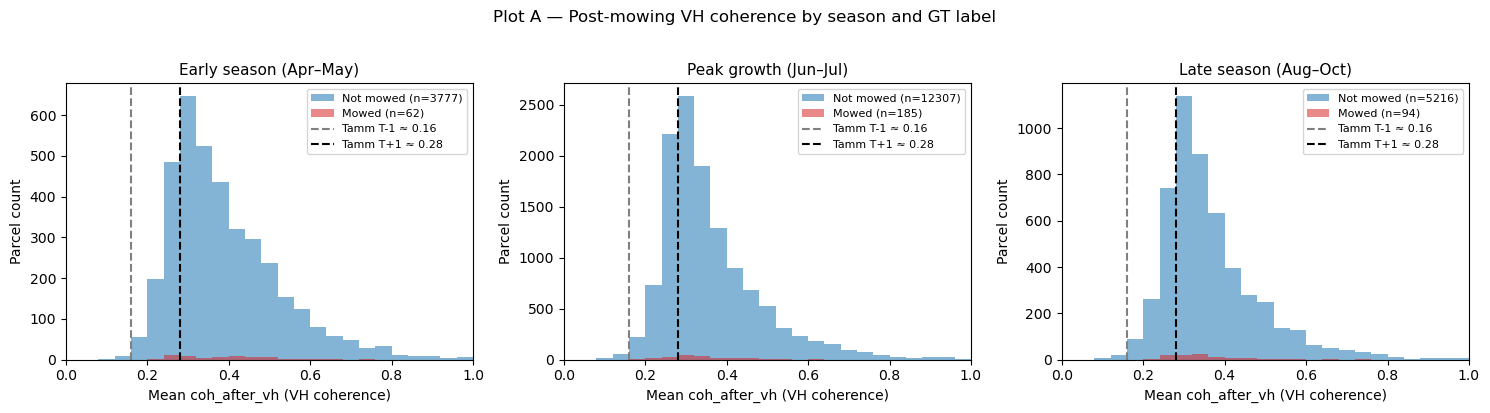

In [16]:
seasons_plot = [s for s in SEASON_ORDER if s in df['season'].unique() and s != 'other']
n_seasons    = len(seasons_plot)

fig, axes = plt.subplots(1, n_seasons, figsize=(5 * n_seasons, 4), sharey=False)
if n_seasons == 1:
    axes = [axes]

colors = {1: '#d62728', 0: '#1f77b4'}
labels_map = {1: 'Mowed', 0: 'Not mowed'}

for ax, season in zip(axes, seasons_plot):
    sub = df[df['season'] == season]
    for lbl in [0, 1]:
        vals = sub[sub['label'] == lbl]['coh_after_vh'].dropna()
        if vals.empty:
            continue
        ax.hist(vals, bins=25, range=(0, 1), alpha=0.55,
                color=colors[lbl], label=f"{labels_map[lbl]} (n={len(vals)})")

    ax.axvline(0.16, color='grey',  linestyle='--', lw=1.5, label='Tamm T-1 ≈ 0.16')
    ax.axvline(0.28, color='black', linestyle='--', lw=1.5, label='Tamm T+1 ≈ 0.28')
    ax.set_title(SEASON_LABELS[season], fontsize=11)
    ax.set_xlabel('Mean coh_after_vh (VH coherence)')
    ax.set_ylabel('Parcel count')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)

plt.suptitle('Plot A — Post-mowing VH coherence by season and GT label', y=1.02)
plt.tight_layout()
plt.savefig(f"{BASE}/data/operational_results/diagnostics/coh_after_vh_histograms.png")
plt.show()


## Plot B — VH coherence jump (coh_after − coh_before), mowed vs not-mowed, by season

If the mowing signal is present, mowed parcels should skew positive.


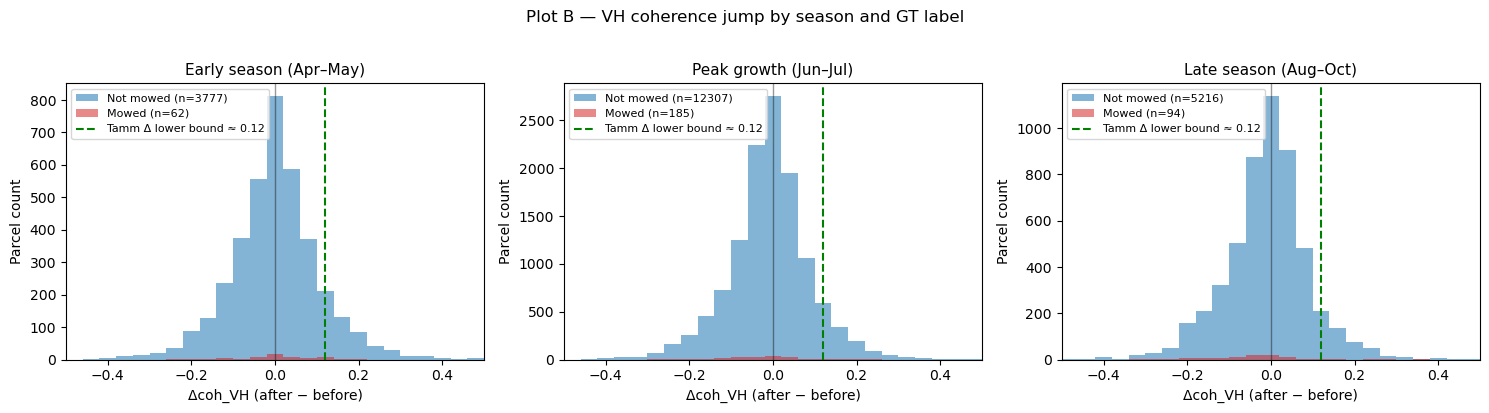

In [17]:
fig, axes = plt.subplots(1, n_seasons, figsize=(5 * n_seasons, 4), sharey=False)
if n_seasons == 1:
    axes = [axes]

for ax, season in zip(axes, seasons_plot):
    sub = df[df['season'] == season]
    for lbl in [0, 1]:
        vals = sub[sub['label'] == lbl]['coh_jump_vh'].dropna()
        if vals.empty:
            continue
        ax.hist(vals, bins=25, range=(-0.5, 0.5), alpha=0.55,
                color=colors[lbl], label=f"{labels_map[lbl]} (n={len(vals)})")

    ax.axvline(0.0,  color='black', linestyle='-',  lw=1, alpha=0.4)
    ax.axvline(0.12, color='green', linestyle='--', lw=1.5,
               label='Tamm Δ lower bound ≈ 0.12')
    ax.set_title(SEASON_LABELS[season], fontsize=11)
    ax.set_xlabel('Δcoh_VH (after − before)')
    ax.set_ylabel('Parcel count')
    ax.legend(fontsize=8)
    ax.set_xlim(-0.5, 0.5)

plt.suptitle('Plot B — VH coherence jump by season and GT label', y=1.02)
plt.tight_layout()
plt.savefig(f"{BASE}/data/operational_results/diagnostics/coh_jump_histograms.png")
plt.show()


## Plot C — VV coherence jump, mowed vs not-mowed, by season

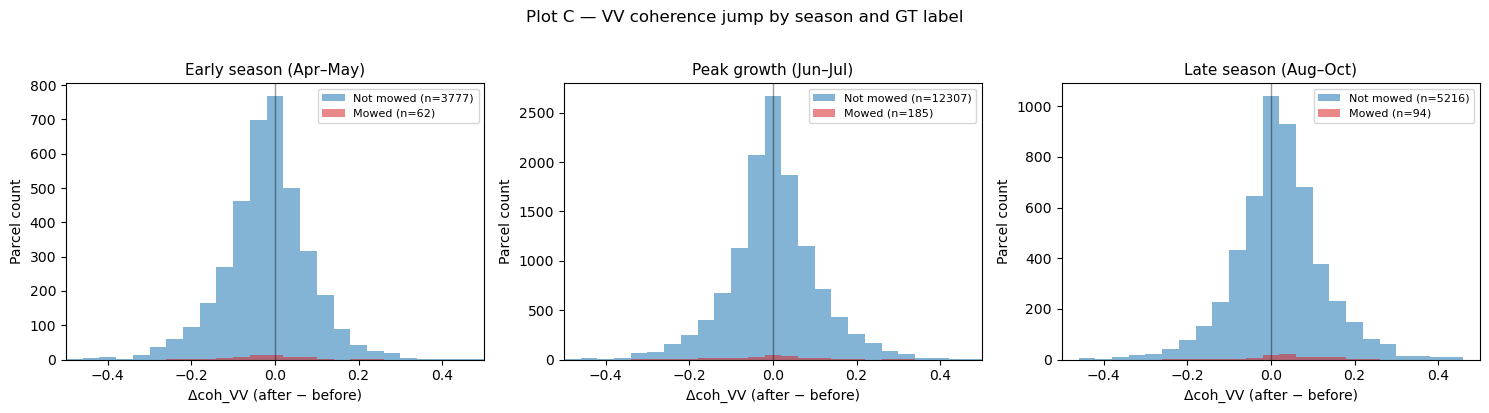

In [18]:
fig, axes = plt.subplots(1, n_seasons, figsize=(5 * n_seasons, 4), sharey=False)
if n_seasons == 1:
    axes = [axes]

for ax, season in zip(axes, seasons_plot):
    sub = df[df['season'] == season]
    for lbl in [0, 1]:
        vals = sub[sub['label'] == lbl]['coh_jump_vv'].dropna()
        if vals.empty:
            continue
        ax.hist(vals, bins=25, range=(-0.5, 0.5), alpha=0.55,
                color=colors[lbl], label=f"{labels_map[lbl]} (n={len(vals)})")

    ax.axvline(0.0, color='black', linestyle='-', lw=1, alpha=0.4)
    ax.set_title(SEASON_LABELS[season], fontsize=11)
    ax.set_xlabel('Δcoh_VV (after − before)')
    ax.set_ylabel('Parcel count')
    ax.legend(fontsize=8)
    ax.set_xlim(-0.5, 0.5)

plt.suptitle('Plot C — VV coherence jump by season and GT label', y=1.02)
plt.tight_layout()
plt.savefig(f"{BASE}/data/operational_results/diagnostics/coh_jump_vv_histograms.png")
plt.show()


## Plot D — coh_before vs coh_after scatter, coloured by GT label, faceted by season

Tamm expected trajectory for mowed events: low before (near diagonal bottom-left),
high after → points **above** the diagonal.
Not-mowed parcels should cluster near the diagonal.


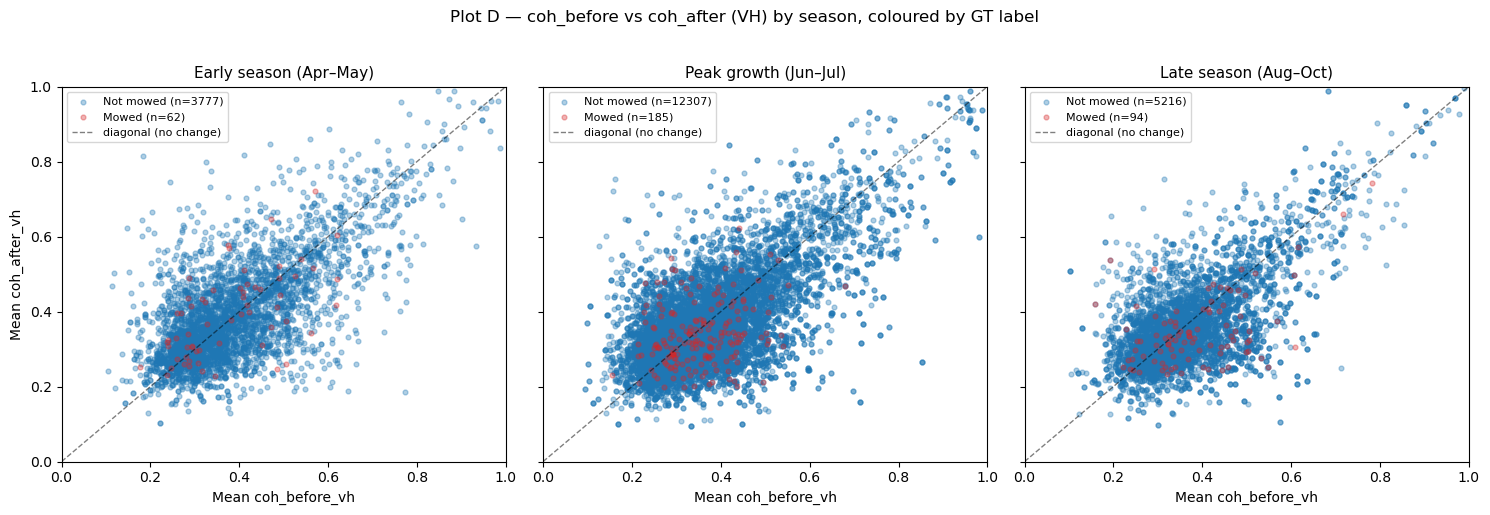

In [19]:
fig, axes = plt.subplots(1, n_seasons, figsize=(5 * n_seasons, 5), sharey=True, sharex=True)
if n_seasons == 1:
    axes = [axes]

for ax, season in zip(axes, seasons_plot):
    sub = df[df['season'] == season]
    for lbl in [0, 1]:
        s = sub[sub['label'] == lbl]
        if s.empty:
            continue
        ax.scatter(s['coh_before_vh'], s['coh_after_vh'],
                   c=colors[lbl], alpha=0.35, s=12,
                   label=f"{labels_map[lbl]} (n={len(s)})")

    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='diagonal (no change)')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Mean coh_before_vh')
    ax.set_title(SEASON_LABELS[season], fontsize=11)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Mean coh_after_vh')
plt.suptitle('Plot D — coh_before vs coh_after (VH) by season, coloured by GT label', y=1.02)
plt.tight_layout()
plt.savefig(f"{BASE}/data/operational_results/diagnostics/coh_before_after_vh_scatter.png")
plt.show()


## Summary Table

In [20]:
def cohens_d(a, b):
    """Cohen's d (mowed - not_mowed) / pooled std."""
    a, b = np.array(a), np.array(b)
    a, b = a[~np.isnan(a)], b[~np.isnan(b)]
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled = np.sqrt(((len(a)-1)*a.std(ddof=1)**2 + (len(b)-1)*b.std(ddof=1)**2)
                     / (len(a) + len(b) - 2))
    return (a.mean() - b.mean()) / pooled if pooled > 0 else np.nan


rows = []
for season in SEASON_ORDER:
    if season not in df['season'].values:
        continue
    sub = df[df['season'] == season]
    for pol, after_col, jump_col in [('VV', 'coh_after_vv', 'coh_jump_vv'),
                                      ('VH', 'coh_after_vh', 'coh_jump_vh')]:
        mow     = sub[sub['label'] == 1][jump_col].dropna()
        not_mow = sub[sub['label'] == 0][jump_col].dropna()
        aft_mow = sub[sub['label'] == 1][after_col].dropna()

        d = cohens_d(mow.values, not_mow.values)
        _, pval = stats.mannwhitneyu(mow, not_mow, alternative='greater')                   if (len(mow) > 1 and len(not_mow) > 1) else (np.nan, np.nan)

        rows.append({
            'Season':            SEASON_LABELS.get(season, season),
            'Pol':               pol,
            'n_mowed':           len(mow),
            'n_not_mowed':       len(not_mow),
            'mean_coh_after_mow':   f"{aft_mow.mean():.3f}" if len(aft_mow) > 0 else 'N/A',
            'mean_jump_mowed':    f"{mow.mean():.3f}"     if len(mow) > 0 else 'N/A',
            'mean_jump_not_mow':  f"{not_mow.mean():.3f}" if len(not_mow) > 0 else 'N/A',
            "Cohen's d":         f"{d:.2f}" if not np.isnan(d) else 'N/A',
            'MW p (mow>not)':    f"{pval:.4f}" if not np.isnan(pval) else 'N/A',
            'Tamm Δ ref':        '0.12–0.14',
        })

summary = pd.DataFrame(rows)
with pd.option_context('display.max_columns', None, 'display.width', 200,
                       'display.colheader_justify', 'left'):
    print(summary.to_string(index=False))


Season                 Pol  n_mowed  n_not_mowed mean_coh_after_mow mean_jump_mowed mean_jump_not_mow Cohen's d MW p (mow>not) Tamm Δ ref
Early season (Apr–May) VV   62       3777        0.347              -0.006          -0.018             0.12     0.2484         0.12–0.14 
Early season (Apr–May) VH   62       3777        0.391               0.011           0.001             0.09     0.1148         0.12–0.14 
 Peak growth (Jun–Jul) VV  185      12307        0.321              -0.011           0.001            -0.11     0.8793         0.12–0.14 
 Peak growth (Jun–Jul) VH  185      12307        0.339              -0.015          -0.009            -0.06     0.9217         0.12–0.14 
 Late season (Aug–Oct) VV   94       5216        0.416               0.046           0.020             0.24     0.0024         0.12–0.14 
 Late season (Aug–Oct) VH   94       5216        0.350              -0.038          -0.009            -0.29     0.9990         0.12–0.14 


## Interpretation

> **Instructions:** Fill in the five lines below based on the plots and table above.
> Delete this block after writing.

1. **Absolute coherence level** — Is `coh_after_vh` for mowed parcels near Tamm's
   0.25–0.30 range, or systematically lower (consistent with the smaller ENL/bias
   predicted by the audit)?

2. **Mowed vs not-mowed separation** — Is there visible distributional separation
   in the jump histograms (Plots B/C) in any season?
   *(No separation → coherence signal is buried in noise or the SNR/window issues
   dominate; clear separation → signal exists despite imperfect preprocessing.)*

3. **Cleanest season** — Which season (early / peak / late) shows the largest
   Cohen's d on the jump? Is this consistent with vegetation phenology
   (shorter, denser grass after summer cut → larger coherence jump)?

4. **VV vs VH** — Which polarization shows larger Cohen's d? Tamm found VH
   more discriminative; does your data agree?

5. **Next step recommendation** — Based on signal quality: proceed to
   classifier training with existing coherence, implement the larger coherence
   window first, or implement the SNR correction first?
